<a href="https://colab.research.google.com/github/fajar22222/muhammad-fajar/blob/main/Prediksi_Volume_Kendaraan_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Penerapan Linear Regression untuk Prediksi Volume Kendaraan Berdasarkan Jam dan Hari dalam Mendukung Transportasi Perkotaan Berkelanjutan

#Mata Kuliah : Kecerdasan Buatan
#SDG 11 sustainable cities and communities


#1. Memuat Data

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Metro_Interstate_Traffic_Volume.csv to Metro_Interstate_Traffic_Volume.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Agar grafik otomatis tampil di Colab
%matplotlib inline

### 2. Pengumpulan Dataset
Memuat dataset `Metro_Interstate_Traffic_Volume.csv` ke dalam DataFrame Pandas dan memeriksa struktur awal data.

In [ ]:
# Membaca dataset dari penyimpanan Colab
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")

# Menampilkan 5 data teratas
display(df.head())

# Menampilkan struktur data dan tipe kolom
print("\n=== INFORMASI DATASET ===")
df.info()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918



=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [ ]:
df.shape

(48204, 9)

### 3. Cleaning & Preprocessing
Melakukan penanganan *missing values* pada kolom `holiday` (mengisi `NaN` dengan `'None'` agar data tidak terhapus), menghapus duplikat, serta mengonversi kolom `date_time` menjadi fitur waktu (`hour`, `day_of_week`, `day_name`, `month`, dan `is_weekend`).

In [ ]:
df['holiday'] = df['holiday'].fillna('None')

# Hapus baris kosong pada kolom penting & hapus duplikat
df = df.dropna(subset=['date_time', 'traffic_volume']).drop_duplicates()

# Konversi format kolom date_time ke datetime
df['date_time'] = pd.to_datetime(df['date_time'])

# Ekstraksi Fitur Waktu
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek  # 0 = Senin, 6 = Minggu
df['day_name'] = df['date_time'].dt.day_name()
df['month'] = df['date_time'].dt.month
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Cek Hasil Preprocessing
print(f"=== TOTAL DATA BERSIH: {len(df)} BARIS ===")
display(df[['date_time', 'hour', 'day_name', 'is_weekend', 'traffic_volume']].head())

NameError: name 'df' is not defined

In [ ]:
# Menampilkan statistik deskriptif untuk fitur angka
df.describe()

,temp,rain_1h,snow_1h,clouds_all,date_time,traffic_volume,hour,day_of_week,month,is_weekend
count,48187.000000,48187.000000,48187.000000,48187.000000,48187,48187.000000,48187.000000,48187.000000,48187.000000,48187.000000
mean,281.204995,0.334382,0.000222,49.365451,2016-01-05 06:49:48.133729024,3259.618134,11.397742,2.984913,6.505240,0.284309
min,0.000000,0.000000,0.000000,0.000000,2012-10-02 09:00:00,0.000000,0.000000,0.000000,1.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,2014-02-06 07:30:00,1192.500000,5.000000,1.000000,4.000000,0.000000
50%,282.450000,0.000000,0.000000,64.000000,2016-06-10 21:00:00,3379.000000,11.000000,3.000000,7.000000,0.000000
75%,291.806000,0.000000,0.000000,90.000000,2017-08-11 05:30:00,4933.000000,17.000000,5.000000,9.000000,1.000000
max,310.070000,9831.300000,0.510000,100.000000,2018-09-30 23:00:00,7280.000000,23.000000,6.000000,12.000000,1.000000
std,13.338738,44.797033,0.008169,39.015213,NaN,1986.954465,6.940373,2.006041,3.400285,0.451089


### 4. Exploratory Data Analysis (EDA)
Menganalisis pola hubungan antara jam, hari, dan volume lalu lintas untuk mendapatkan wawasan awal mengenai jam sibuk (*rush hour*).

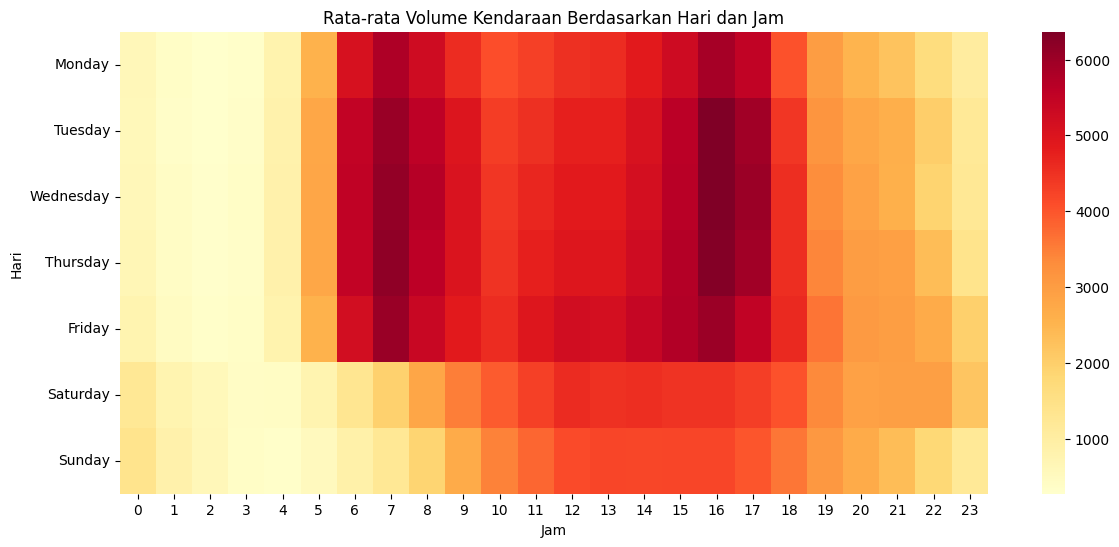

In [51]:
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

pivot = df.pivot_table(
    values='traffic_volume',
    index='day_name',
    columns='hour',
    aggfunc='mean'
).reindex(day_order)

plt.figure(figsize=(14, 6))

sns.heatmap(
    pivot,
    cmap='YlOrRd'
)

plt.title('Rata-rata Volume Kendaraan Berdasarkan Hari dan Jam')
plt.xlabel('Jam')
plt.ylabel('Hari')

plt.show()

In [ ]:
hourly_volume = (
    df.groupby('hour')['traffic_volume']
    .mean()
    .sort_values(ascending=False)
)

print("=== 5 JAM DENGAN RATA-RATA VOLUME TERTINGGI ===")

display(
    hourly_volume
    .head(5)
    .to_frame('Rata-rata Volume Kendaraan')
)

peak_hour = hourly_volume.idxmax()
peak_volume = hourly_volume.max()

print(f"\nJam dengan volume tertinggi: {peak_hour:02d}:00")
print(f"Rata-rata volume: {peak_volume:.0f} kendaraan")

=== 5 JAM DENGAN RATA-RATA VOLUME TERTINGGI ===


,Rata-rata Volume Kendaraan
hour,
16,5663.756539
17,5310.076048
15,5240.459907
14,4931.888776
7,4740.181337



Jam dengan volume tertinggi: 16:00
Rata-rata volume: 5664 kendaraan


### 5. Feature Selection & Encoding
Memilih variabel independen (`hour`, `day_of_week`, `is_weekend`, `month`) dan menerapkan One-Hot Encoding agar algoritma *Linear Regression* dapat mempelajari hubungan fluktuasi jam sibuk.

In [ ]:
# Memilih fitur prediktor
features = ['hour', 'day_of_week', 'is_weekend', 'month']

# Penerapan One-Hot Encoding pada fitur kategorikal jam dan hari
X = pd.get_dummies(df[features], columns=['hour', 'day_of_week'], drop_first=True)
y = df['traffic_volume']

print("=== HASIL FEATURE ENCODING ===")
print(f"Jumlah sampel (baris) : {X.shape[0]}")
print(f"Jumlah fitur  (kolom) : {X.shape[1]}")

=== HASIL FEATURE ENCODING ===
Jumlah sampel (baris) : 48187
Jumlah fitur  (kolom) : 31


### 6. Pembagian Data Training dan Testing
Membagi data menjadi **Data Training (80%)** untuk pelatihan model dan **Data Uji (20%)** untuk pengujian performa.

In [ ]:
# Pastikan data sudah diurutkan berdasarkan waktu
df = df.sort_values('date_time').reset_index(drop=True)

# Menentukan batas 80% data untuk training
split_index = int(len(X) * 0.8)

# Data training = periode awal
X_train = X.iloc[:split_index].copy()
y_train = y.iloc[:split_index].copy()

# Data testing = periode setelah data training
X_test = X.iloc[split_index:].copy()
y_test = y.iloc[split_index:].copy()

print("data training :", len(X_train))
print("data testing  :", len(X_test))

print("\nPeriode Training:")
print(df['date_time'].iloc[0], "sampai", df['date_time'].iloc[split_index-1])

print("\nPeriode Testing:")
print(df['date_time'].iloc[split_index], "sampai", df['date_time'].iloc[-1])

data training : 38549
data testing  : 9638

Periode Training:
2012-10-02 09:00:00 sampai 2017-11-01 19:00:00

Periode Testing:
2017-11-01 20:00:00 sampai 2018-09-30 23:00:00


### 7. Pemodelan Machine Learning
Melatih 2 algoritma Regresi:
1. **Linear Regression** (Algoritma Utama)
2. **Random Forest Regressor** (Algoritma Pembanding)

In [ ]:
# 1. Inisialisasi dan Pelatihan Linear Regression
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# 2. Inisialisasi dan Pelatihan Random Forest Regressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

print("Proses pelatihan kedua model berhasil dilakukan!")

Proses pelatihan kedua model berhasil dilakukan!


### 8. Evaluasi Model
Mengukur akurasi dan tingkat kesalahan model pada data uji menggunakan metrik **MAE**, **RMSE**, dan **R² Score**.

,Model,MAE,RMSE,R2 Score
0,Linear Regression,601.292776,833.142031,0.820706
1,Random Forest Regressor,299.455422,534.328698,0.926253


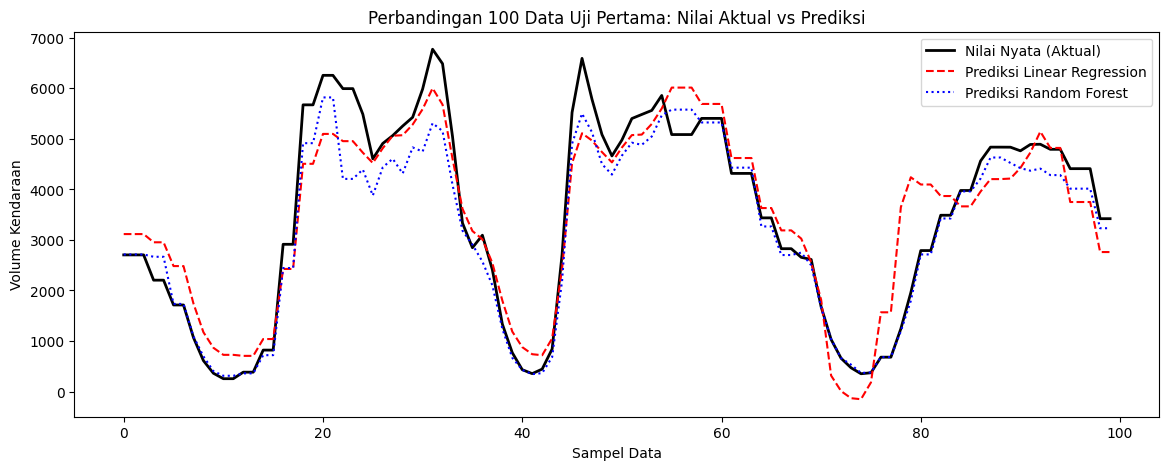

In [50]:
# Prediksi data uji
y_pred_lr = model_lr.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

# Fungsi perhitungan metrik
def calculate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2 Score': r2}

# Menampilkan hasil evaluasi
evaluation_results = pd.DataFrame([
    calculate_metrics(y_test, y_pred_lr, 'Linear Regression'),
    calculate_metrics(y_test, y_pred_rf, 'Random Forest Regressor')
])

display(evaluation_results)

# Grafik Visualisasi Perbandingan Nilai Nyata vs Prediksi (100 Sampel Pertama)
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:100], label='Nilai Nyata (Aktual)', color='black', linewidth=2)
plt.plot(y_pred_lr[:100], label='Prediksi Linear Regression', color='red', linestyle='--')
plt.plot(y_pred_rf[:100], label='Prediksi Random Forest', color='blue', linestyle=':')
plt.title('Perbandingan 100 Data Uji Pertama: Nilai Aktual vs Prediksi', fontsize=12)
plt.xlabel('Sampel Data')
plt.ylabel('Volume Kendaraan')
plt.legend()
plt.show()

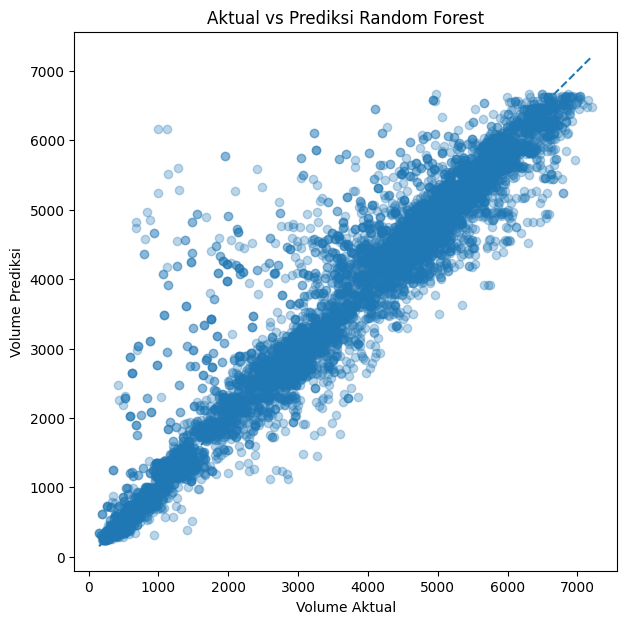

In [ ]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.3
)

nilai_min = min(y_test.min(), y_pred_rf.min())
nilai_max = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [nilai_min, nilai_max],
    [nilai_min, nilai_max],
    linestyle='--'
)

plt.xlabel('Volume Aktual')
plt.ylabel('Volume Prediksi')
plt.title('Aktual vs Prediksi Random Forest')

plt.show()

### 9. Prediksi & Interpretasi
Menguji model pada satu sampel spesifik untuk melihat seberapa akurat hasil prediksi dibandingkan nilai sebenarnya.

In [ ]:
# Mengambil 1 sampel data uji
sample_index = 0
sample_x = X_test.iloc[[sample_index]]
actual_value = y_test.iloc[sample_index]

# Prediksi dari kedua model
pred_lr = model_lr.predict(sample_x)[0]
pred_rf = model_rf.predict(sample_x)[0]

print("=== HASIL SIMULASI PREDIKSI SAMPEL ===")
print(f"Volume Kendaraan Nyata (Aktual) : {actual_value:.0f} kendaraan")
print(f"Prediksi Linear Regression      : {pred_lr:.0f} kendaraan")
print(f"Prediksi Random Forest          : {pred_rf:.0f} kendaraan")

=== HASIL SIMULASI PREDIKSI SAMPEL ===
Volume Kendaraan Nyata (Aktual) : 2704 kendaraan
Prediksi Linear Regression      : 3147 kendaraan
Prediksi Random Forest          : 2748 kendaraan


### 10. Kesimpulan
1. **Pola Jam Sibuk:** Lonjakan lalu lintas terbesar terjadi pada jam berangkat kerja (pukul 07:00–08:00) dan jam pulang kerja (pukul 16:00–17:00) pada hari kerja (Senin–Jumat).
2. **Kinerja Model:** Model *Linear Regression* berhasil memprediksi tren volume lalu lintas berdasarkan komponen jam dan hari, sementara *Random Forest Regressor* memberikan tingkat keakuratan (*R² Score*) yang lebih tinggi karena mampu menangkap pola non-linear secara optimal.